In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from  sklearn.model_selection import train_test_split


In [2]:
df = load_diabetes(as_frame = True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.shape

(442, 11)

In [16]:
X= df.drop("target", axis = 1)
y = df["target"]

In [17]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [18]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [19]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.3,random_state=42)

In [34]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth = 7,min_samples_leaf=20)
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [36]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred_train = model.predict(X_train) 
y_pred_test = model.predict(X_test) 

print("mse for train:",mean_squared_error(y_train,y_pred_train))
print("mse for test:",mean_squared_error(y_test,y_pred_test))


print("r2_score for train:",r2_score(y_train,y_pred_train))
print("r2_score for test:",r2_score(y_test,y_pred_test))

mse for train: 2795.7093704335157
mse for test: 3177.664925233041
r2_score for train: 0.5452860742356658
r2_score for test: 0.41135906558189406


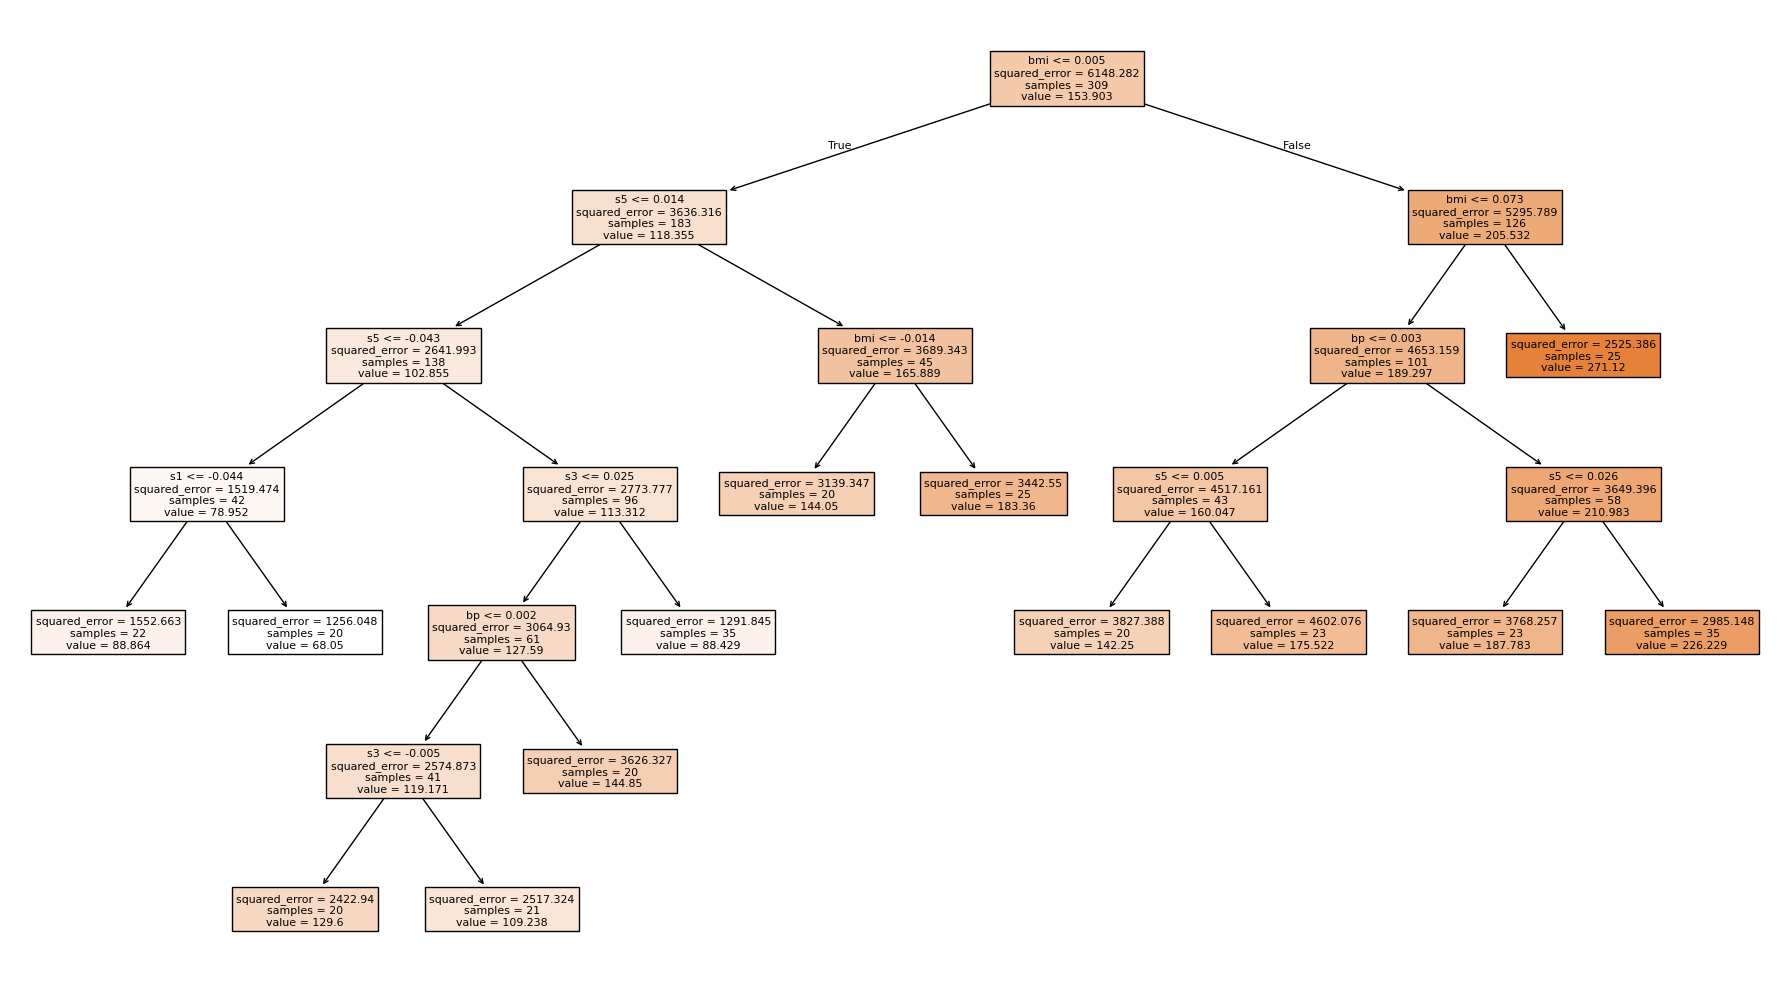

In [37]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    
)
plt.tight_layout()